### Sequential Monte Carlo Samplers

- This is a method to systematically build a list of intermediate distribution $\pi_0, \pi_1, ... \pi_T$ that will sample from target $\pi_T$ efficiently.

- This method is a combination of multiple techniques in statistic namely **Importance Sampling**, **Resampling** and **MCMC with good move**
 
- Can find more details here: https://arxiv.org/pdf/2007.11936

### Challenges 

- As could be seen from the notebook mcmc, **Parallel Tempering with Replica Exchange** required the good build of intermediate distributions or else the sample will not well-represent underlying distribution.

- In this notebook, the author will first construct by hand the $\pi_i$ distribution, apply the algorithm to make a sample from the target one through those intermediate.

- Then the intermediate distribution will be constructed automatically base on the paper result.

For start, let's just use the old 2 mode distribution we have use in mcmc notebook. 

In [5]:
from jax import numpy as jnp
from scipy.stats import norm

def log_target_pdf(x):
     return jnp.logaddexp(
         jnp.log(0.5) + norm(loc = 3, scale = 0.5).logpdf(x), 
         jnp.log(0.5) + norm(loc = -3, scale = 0.5).logpdf(x),  
     )

Let's now plotting the distribution again

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_30370/3802190487.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_30370/3802190487.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


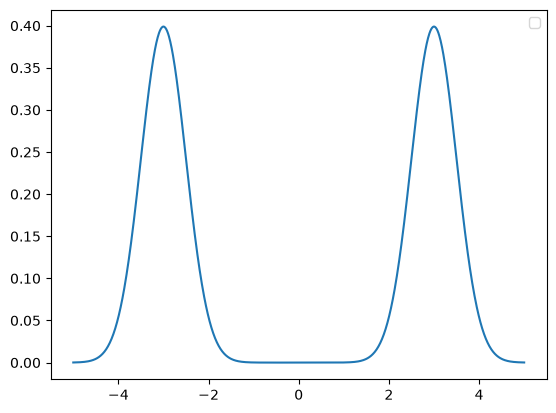

In [6]:
from jax import numpy as jnp
from matplotlib import pyplot as plt 

fig, ax = plt.subplots()
xx = jnp.linspace(-5, 5, 1000)
yy = jnp.exp(log_target_pdf(xx))

ax.plot(xx, yy)

plt.legend()
fig.show()

Now let's first assume we have successfully found a list of $\pi_0, \pi_1, ..\pi_T$

Let implement some sampling method that is a bit different with what we have in previous notebook like **Parallel Tempering**, the method now will generate all samples for each intermediate distributions instead of the generate-and-swap between sequential pair of distributions. 

For simplicity, $\pi_0$ will always be Gaussian distribution. 

In [11]:
import copy 
from tqdm import trange

# The code below yank from previous notebook with some optimization 

class AcceptanceTracker(object):
    def __init__(self):
        self.__accept_count = 0
        self.__total_count = 0 

    def record(self, cur_state, next_state):
        if cur_state is not next_state: 
            self.__accept_count += 1

        self.__total_count += 1 

    def reset(self):
        self.__accept_count = 0
        self.__total_count = 0 

    def get_acceptance_rate(self):
        return self.__accept_count / self.__total_count 


def mcmc(initial_state, log_pdf_fn, proposed_fn, iters = 10000, tracker = None):
    state_list = [initial_state]
    cur_state_log_pdf = log_pdf_fn(cur_state)
    
    for _ in trange(iters):
        cur_state = state_list[-1] 
        proposed_state = proposed_fn(cur_state)
        next_state_log_pdf = log_pdf_fn(proposed_state) 
        log_diff = min(next_state_log_pdf - cur_state_log_pdf, 0)
        next_state = proposed_state if (log_diff > np.log(np.random.uniform(0, 1))) else cur_state 
        if tracker: 
            tracker.record(cur_state, next_state)

        cur_state_log_pdf = next_state_log_pdf
        state_list.append(copy.deepcopy(next_state))

    return state_list 

In [12]:
from tqdm import trange
from jax import numpy as jnp 

class SMC: 
    def __init__(self, dims, target_dist_logpdf):
        self.__dims = dims 
        self.__target_dist_logpdf = target_dist_logpdf
        self.__inter_dists = [target_dist_logpdf]
        self.__cur_dist_id = 0
        self.__cur_samples = []

    # loop to sample from distributions 
    def sample_loop(self, no_samples: int):
        self.reset()
        for _ in trange(len(self.__inter_dists) - 1):
            self.__sample_next_dist()

        assert()
    
    # apply importance sampling and re-sampling to sample next distribution from current distribution  
    def __sample_next_dist(self):
        assert cur_dist_id < len(self.__inter_dists) - 1 
        self.__cur_dist_id += 1 
        # reweight the to next dist 

        # re-sample next distribution base on the current samples 

        # mcmc to avoid repeated value in resamples  
        
        ...  
        

    # automatically build the intermediate distribs from pi_0 to pi_T 
    def build_intermediate_dists(self):
        # try to find the next lambda such that ESS((pi_1 / pi_0) ^ next_lambda -cur_lambda) >= 0.75 
        # do that using Binary search and continue until all adjacent ESS of intermediate dists >= 0.75
        ... 

    def reset(self):
        self.__cur_dist_id = 0 
        self.__cur_samples = jnp.random.multivariate_normal(size = self.__dims)